In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import random
import jax

import pollux as plx
from pollux.models.transforms import LinearTransform

from process_rvs import process_spectra

jax.config.update("jax_enable_x64", True)

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

In [86]:
training_dwarfs_sdss = pd.read_pickle('data/training_set_dwarfs.pkl')
training_giants_sdss = pd.read_pickle('data/training_set_giants.pkl')

lux_pred_giants = pd.read_csv("data/giants_predicted_with_alpha_m.csv")
lux_pred_dwarfs = pd.read_csv("data/dwarfs_predicted_with_alpha_m.csv")

training_sdss_all = pd.concat([training_giants_sdss, training_dwarfs_sdss], ignore_index=True)
lux_pred_all = pd.concat([lux_pred_giants, lux_pred_dwarfs], ignore_index=True)

# Find training set stars in Lux predicted values

In [87]:
dwarfs_mask = lux_pred_dwarfs['source_id'].isin(training_dwarfs_sdss['source_id'])
lux_pred_training_dwarfs = lux_pred_dwarfs[dwarfs_mask]

giants_mask = lux_pred_giants['source_id'].isin(training_giants_sdss['source_id'])
lux_pred_training_giants = lux_pred_giants[giants_mask]

all_mask = lux_pred_all['source_id'].isin(training_sdss_all['source_id'])
lux_pred_training_all = lux_pred_all[all_mask]

In [88]:
lux_ids = lux_pred_all['source_id']
match_mask = training_sdss_all['source_id'].isin(lux_ids)
training_in_lux = training_sdss_all[match_mask]

In [89]:
combined_lux_training = pd.merge(
    lux_pred_all, 
    training_sdss_all, 
    on='source_id', 
    how='inner', 
    suffixes=('_lux', '_sdss')
)

In [90]:
#combined_lux_training['teff_unc'] = np.abs(combined_lux_training['teff_sdss'] - combined_lux_training['teff_lux'])
combined_lux_training['teff_res'] = combined_lux_training['teff_sdss'] - combined_lux_training['teff_lux']

In [91]:
gaia_df = pd.read_csv("data/gaia_IDs_and_colors.csv")
gaia_df.head()

,source_id,ra,dec,parallax,pmra,pmdec,radial_velocity,rvs_spec_sig_to_noise,teff_gspphot,logg_gspphot,mh_gspphot,phot_g_mean_mag,phot_rp_mean_mag,phot_bp_mean_mag
0,1158184012071254400,224.580705,4.759718,NaN,NaN,NaN,19.736637,128.47984,NaN,NaN,NaN,9.909913,9.081639,10.632524
1,458111077340747776,39.056693,57.728070,2.801820,8.709150,-3.880525,-5.394361,196.07227,NaN,NaN,NaN,8.862565,8.760913,8.895749
2,458111798895251072,39.148392,57.720606,2.804736,8.891490,-3.863349,-0.544152,242.61273,NaN,NaN,NaN,8.447208,8.353966,8.475003
3,458182957914380032,38.653083,58.189299,0.605749,3.157653,-1.858103,-18.019020,172.87813,NaN,NaN,NaN,10.574236,9.153232,13.172504
4,458388188632487040,35.849756,56.854216,1.462591,1.811199,-5.075412,-8.475615,218.92624,NaN,NaN,NaN,8.528695,8.353546,8.600220


In [92]:
gaia_snr_df = gaia_df[['source_id', 'rvs_spec_sig_to_noise']]

# 3. Merge into the giants dataframe
combined_lux_training = combined_lux_training.merge(
    gaia_snr_df, 
    on='source_id', 
    how='left'
)

Text(0, 0.5, '[Fe/H] from Lux (predicted)')

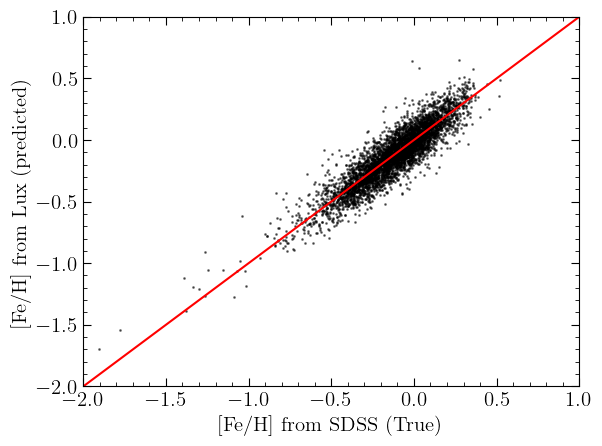

In [109]:
plt.scatter(combined_lux_training['fe_h_sdss'], combined_lux_training['fe_h_lux'], s = 1, alpha = 0.5, color = 'black')
plt.plot([-2, 1], [-2, 1], color = 'red')
plt.xlim(-2, 1)
plt.ylim(-2, 1)
plt.xlabel("[Fe/H] from SDSS (True)")
plt.ylabel("[Fe/H] from Lux (predicted)")

Text(0, 0.5, 'Teff from Lux (predicted)')

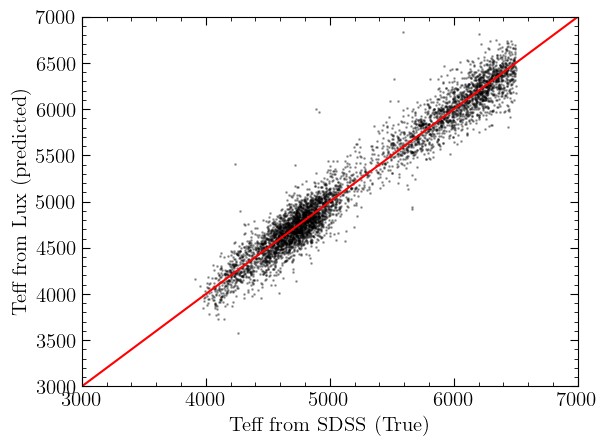

In [112]:
plt.scatter(combined_lux_training['teff_sdss'], combined_lux_training['teff_lux'], s = 1, color = 'black', alpha = 0.3)
plt.plot([3000, 7000], [3000, 7000], color = 'red')
plt.xlim(3000, 7000)
plt.ylim(3000, 7000)
plt.xlabel("Teff from SDSS (True)")
plt.ylabel("Teff from Lux (predicted)")

In [113]:
#combined_lux_training['teff_unc'] = np.abs(combined_lux_training['teff_sdss'] - combined_lux_training['teff_lux'])
combined_lux_training['teff_res'] = combined_lux_training['teff_sdss'] - combined_lux_training['teff_lux']

Text(0, 0.5, 'Teff residuals')

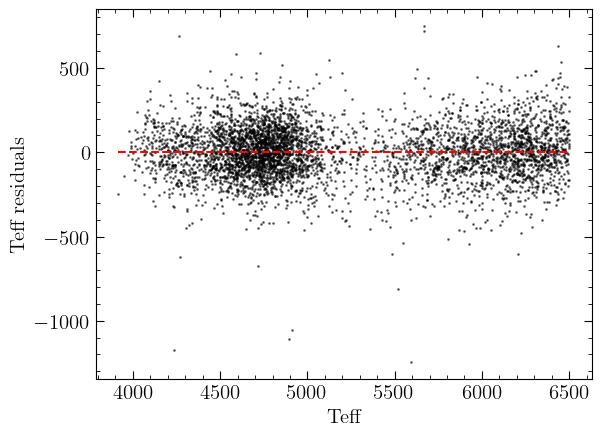

In [116]:
plt.scatter(combined_lux_training['teff_sdss'], combined_lux_training['teff_res'], s = 1, color = 'black', alpha = 0.5)
plt.plot([min(combined_lux_training['teff_sdss']), max(combined_lux_training['teff_sdss'])], [0, 0], color = 'red', linestyle = '--')
plt.xlabel("Teff")
plt.ylabel("Teff residuals")

Text(0.5, 0, 'APOGEE SNR')

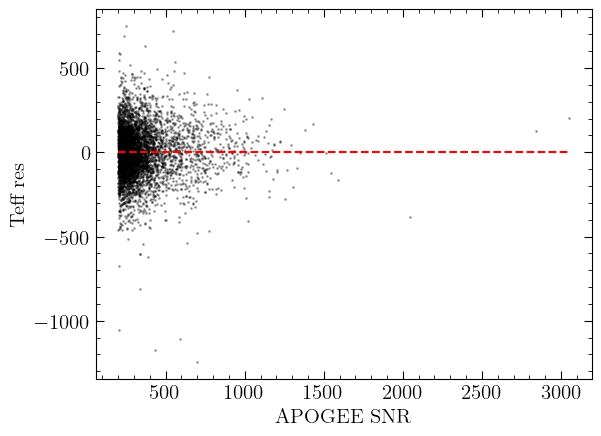

In [120]:
plt.scatter(combined_lux_training['snr'], combined_lux_training['teff_res'], s = 1, color = 'black', alpha = 0.3)
plt.plot([min(combined_lux_training['snr']), max(combined_lux_training['snr'])], [0, 0], color = 'red', linestyle = '--')
plt.ylabel("Teff res")
plt.xlabel("APOGEE SNR")

add SNRs from Gaia and make plots based on that. Need to be done through get training set stuff


In [99]:
gaia_df = pd.read_csv("data/gaia_IDs_and_colors.csv")
gaia_df.head()

,source_id,ra,dec,parallax,pmra,pmdec,radial_velocity,rvs_spec_sig_to_noise,teff_gspphot,logg_gspphot,mh_gspphot,phot_g_mean_mag,phot_rp_mean_mag,phot_bp_mean_mag
0,1158184012071254400,224.580705,4.759718,NaN,NaN,NaN,19.736637,128.47984,NaN,NaN,NaN,9.909913,9.081639,10.632524
1,458111077340747776,39.056693,57.728070,2.801820,8.709150,-3.880525,-5.394361,196.07227,NaN,NaN,NaN,8.862565,8.760913,8.895749
2,458111798895251072,39.148392,57.720606,2.804736,8.891490,-3.863349,-0.544152,242.61273,NaN,NaN,NaN,8.447208,8.353966,8.475003
3,458182957914380032,38.653083,58.189299,0.605749,3.157653,-1.858103,-18.019020,172.87813,NaN,NaN,NaN,10.574236,9.153232,13.172504
4,458388188632487040,35.849756,56.854216,1.462591,1.811199,-5.075412,-8.475615,218.92624,NaN,NaN,NaN,8.528695,8.353546,8.600220


In [100]:
gaia_snr_df = gaia_df[['source_id', 'rvs_spec_sig_to_noise']]

# 3. Merge into the giants dataframe
combined_lux_training = combined_lux_training.merge(
    gaia_snr_df, 
    on='source_id', 
    how='left'
)

Text(0.5, 0, 'Gaia SNR')

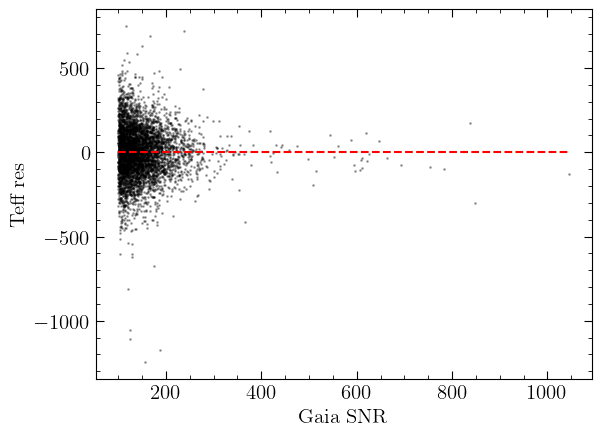

In [ ]:
plt.scatter(combined_lux_training['rvs_spec_sig_to_noise'], combined_lux_training['teff_res'], s = 1, color = 'black', alpha = 0.3)
plt.plot([min(combined_lux_training['rvs_spec_sig_to_noise']), max(combined_lux_training['rvs_spec_sig_to_noise'])], [0, 0], color = 'red', linestyle = '--')
plt.ylabel("Teff res")
plt.xlabel("Gaia SNR")

In [129]:
combined_lux_training['teff_res'] = combined_lux_training['teff_sdss'] - combined_lux_training['teff_lux']
combined_lux_training['logg_res'] = combined_lux_training['logg_sdss'] - combined_lux_training['logg_lux']
combined_lux_training['fe_h_res'] = combined_lux_training['fe_h_sdss'] - combined_lux_training['fe_h_lux']
combined_lux_training['mg_h_res'] = combined_lux_training['mg_h_sdss'] - combined_lux_training['mg_h_lux']
combined_lux_training['n_h_res'] = combined_lux_training['n_h_sdss'] - combined_lux_training['n_h_lux']
combined_lux_training['si_h_res'] = combined_lux_training['si_h_sdss'] - combined_lux_training['si_h_lux']
combined_lux_training['ni_h_res'] = combined_lux_training['ni_h_sdss'] - combined_lux_training['ni_h_lux']
combined_lux_training['ca_h_res'] = combined_lux_training['ca_h_sdss'] - combined_lux_training['ca_h_lux']
combined_lux_training['ce_h_res'] = combined_lux_training['ce_h_sdss'] - combined_lux_training['ce_h_lux']
combined_lux_training['m_h_atm_res'] = combined_lux_training['m_h_atm_sdss'] - combined_lux_training['m_h_atm_lux']
combined_lux_training['alpha_m_atm_res'] = combined_lux_training['alpha_m_atm_sdss'] - combined_lux_training['alpha_m_atm_lux']

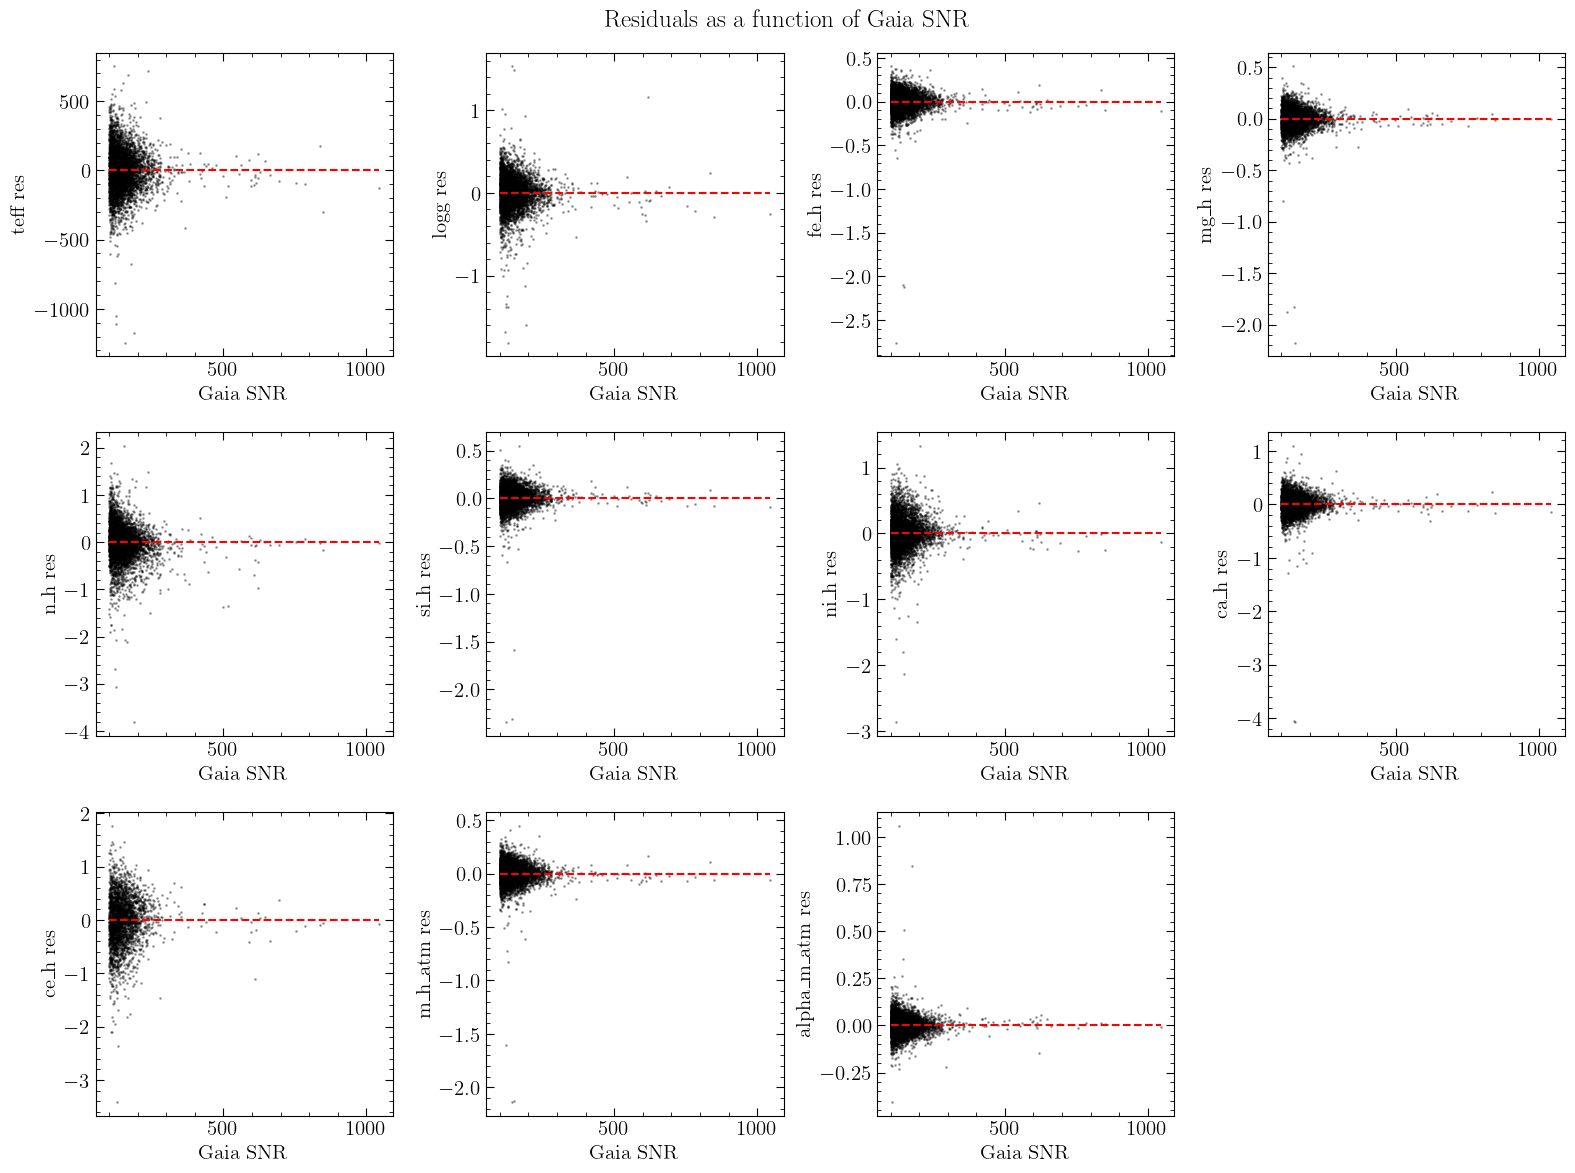

In [132]:
import matplotlib.pyplot as plt

features = [
    'teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 
    'ni_h', 'ca_h', 'ce_h', 'm_h_atm', 'alpha_m_atm'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

snr = combined_lux_training['rvs_spec_sig_to_noise']
snr_min, snr_max = snr.min(), snr.max()

for i in range(len(axes)):
    if i < len(features):
        feature = features[i]
        res_col = f'{feature}_res'
        
        axes[i].scatter(snr, combined_lux_training[res_col], s=1, color='black', alpha=0.3)
        axes[i].plot([snr_min, snr_max], [0, 0], color='red', linestyle='--')
        
        axes[i].set_ylabel(f"{feature} res")
        axes[i].set_xlabel("Gaia SNR")
    else:
        fig.delaxes(axes[i]) 

plt.suptitle("Residuals as a function of Gaia SNR")
plt.tight_layout()
plt.show()

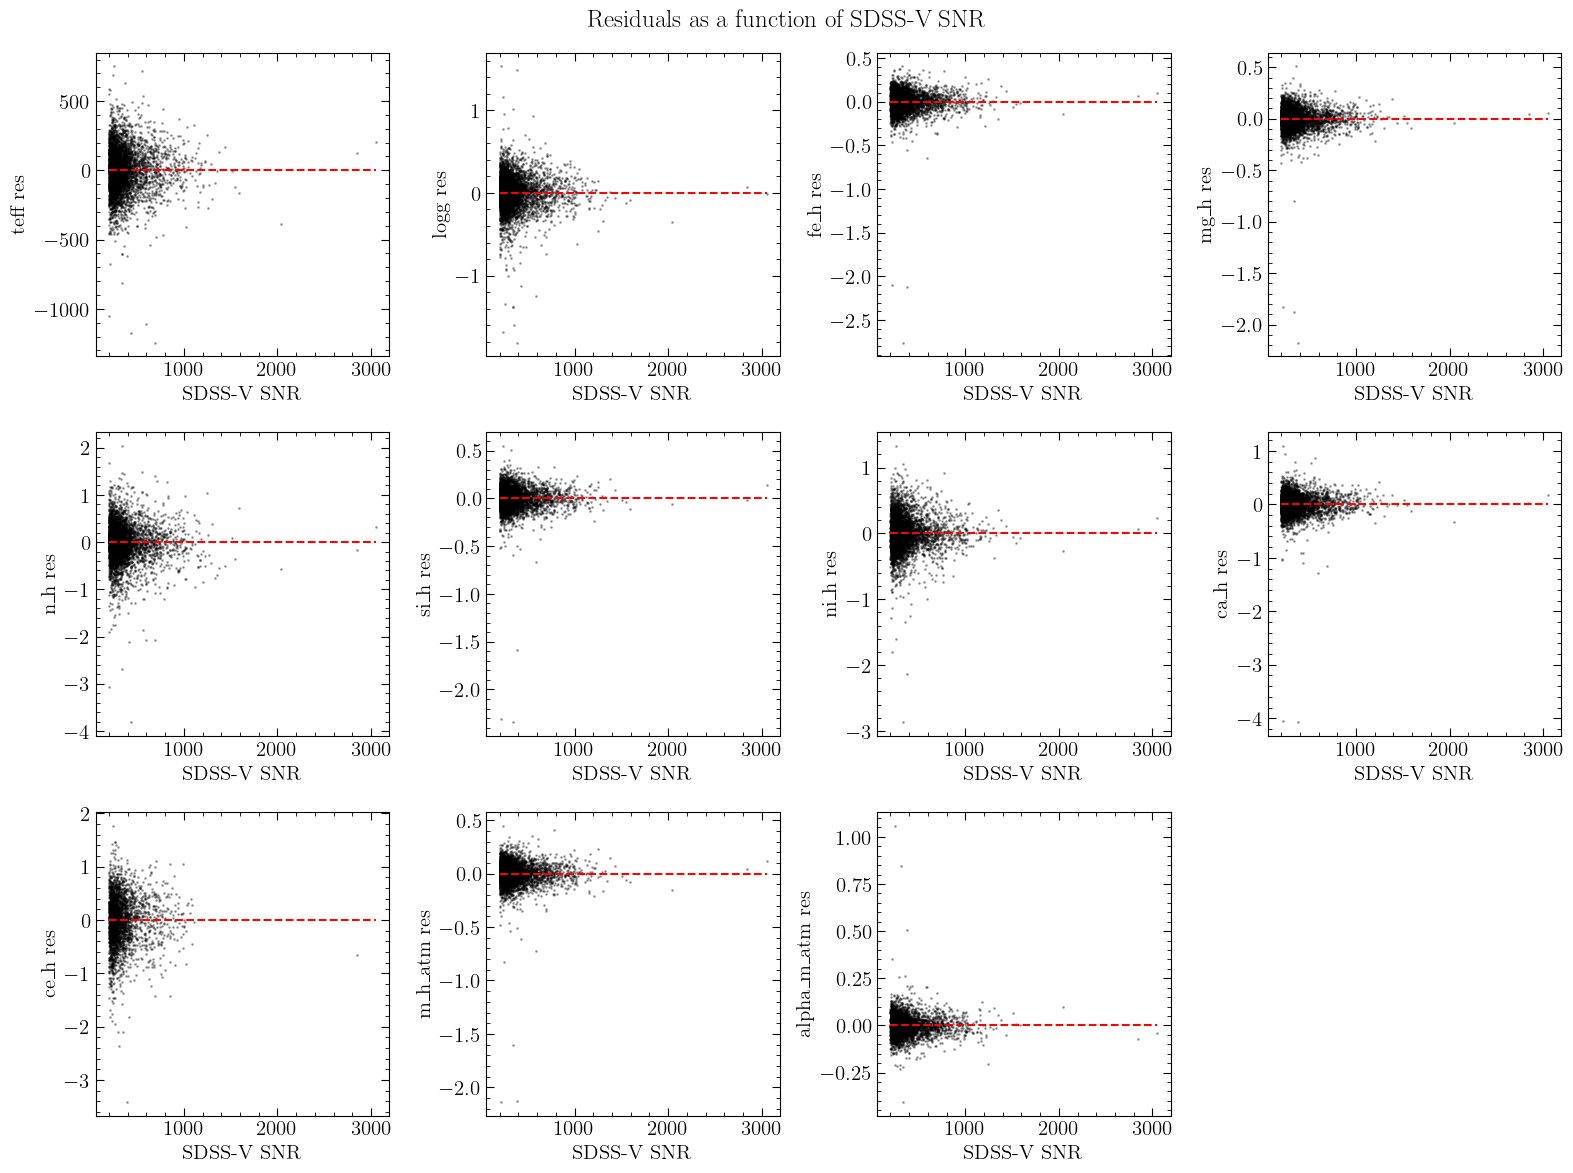

In [137]:
import matplotlib.pyplot as plt

features = [
    'teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 
    'ni_h', 'ca_h', 'ce_h', 'm_h_atm', 'alpha_m_atm'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

snr = combined_lux_training['snr']
snr_min, snr_max = snr.min(), snr.max()

for i in range(len(axes)):
    if i < len(features):
        feature = features[i]
        res_col = f'{feature}_res'
        
        axes[i].scatter(snr, combined_lux_training[res_col], s=1, color='black', alpha=0.3)
        axes[i].plot([snr_min, snr_max], [0, 0], color='red', linestyle='--')
        
        axes[i].set_ylabel(f"{feature} res")
        axes[i].set_xlabel("SDSS-V SNR")
    else:
        fig.delaxes(axes[i]) 

plt.suptitle("Residuals as a function of SDSS-V SNR")
plt.tight_layout()
plt.show()

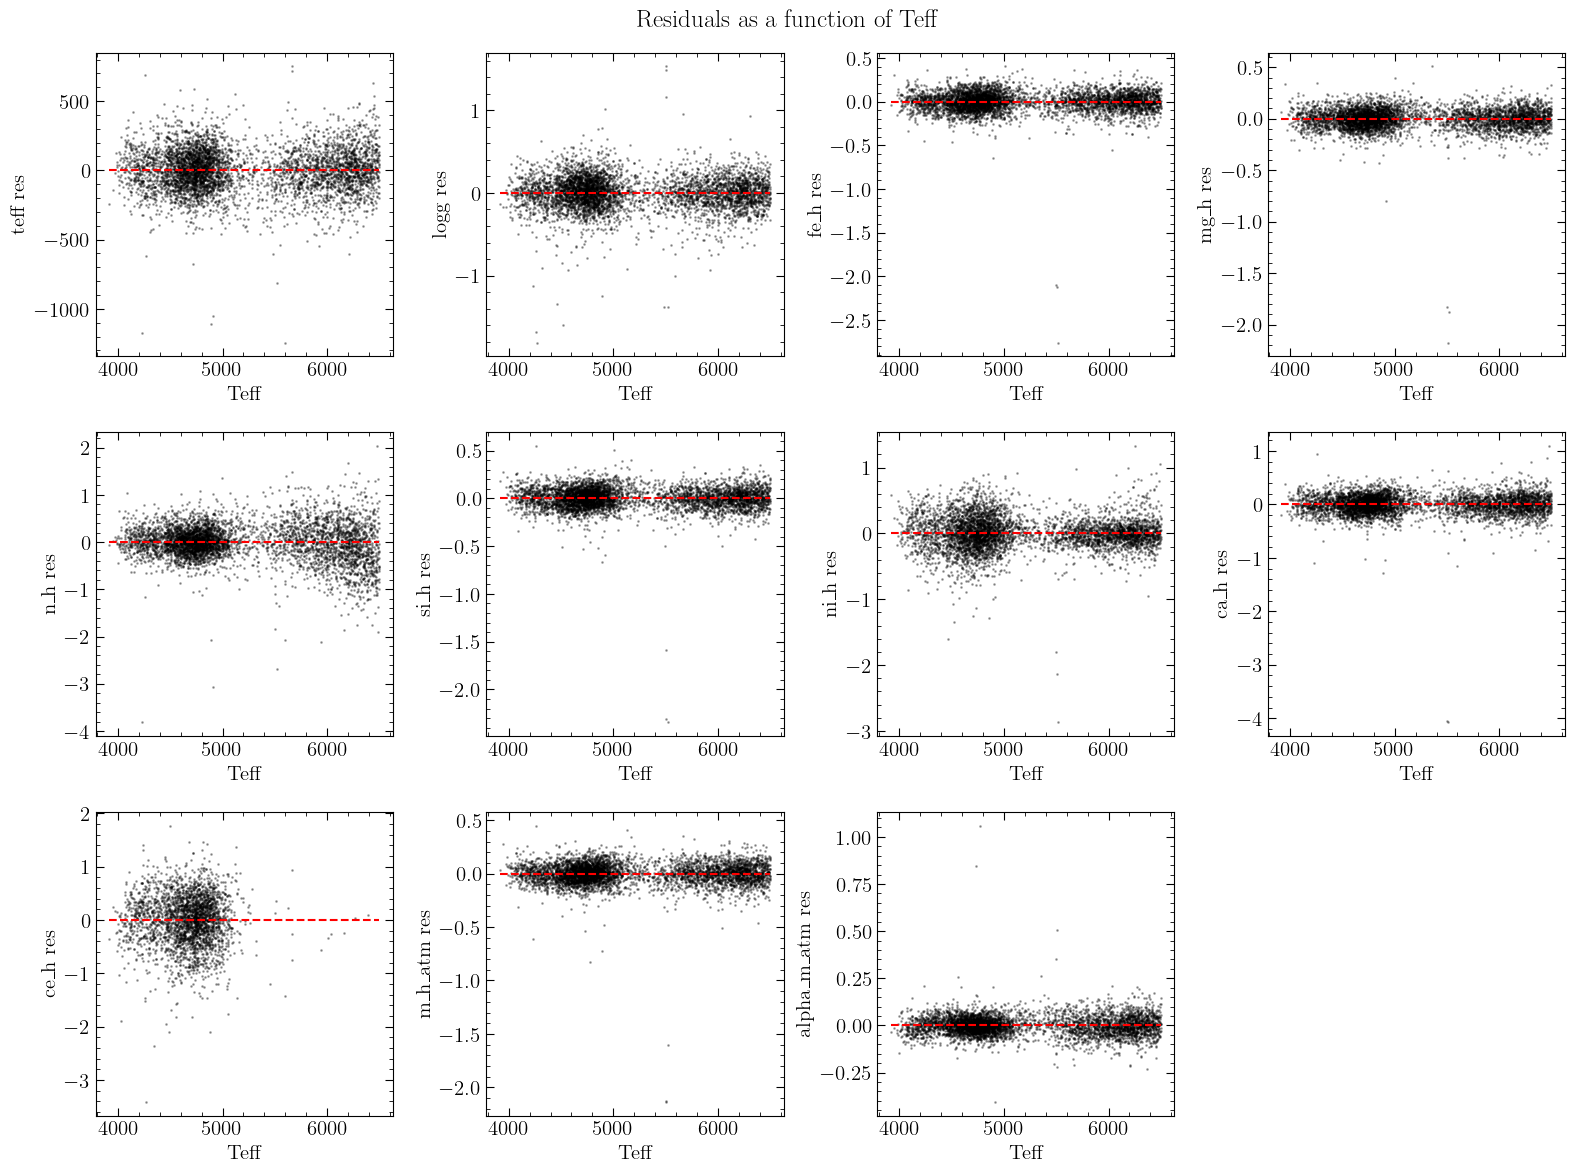

In [136]:
import matplotlib.pyplot as plt

features = [
    'teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 
    'ni_h', 'ca_h', 'ce_h', 'm_h_atm', 'alpha_m_atm'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

snr = combined_lux_training['teff_sdss']
snr_min, snr_max = snr.min(), snr.max()

for i in range(len(axes)):
    if i < len(features):
        feature = features[i]
        res_col = f'{feature}_res'
        
        axes[i].scatter(snr, combined_lux_training[res_col], s=1, color='black', alpha=0.3)
        axes[i].plot([snr_min, snr_max], [0, 0], color='red', linestyle='--')
        
        axes[i].set_ylabel(f"{feature} res")
        axes[i].set_xlabel("Teff")
    else:
        fig.delaxes(axes[i]) 

plt.suptitle("Residuals as a function of Teff")
plt.tight_layout()
plt.show()